In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
data=pd.read_csv(r"E:\Imarticus\Machine Learning\Date set\income_data.csv")
data

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
...,...,...,...
493,494,5.249209,4.568705
494,495,3.471799,2.535002
495,496,6.087610,4.397451
496,497,3.440847,2.070664


In [3]:
data.head()

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [5]:
data.dtypes

Unnamed: 0      int64
income        float64
happiness     float64
dtype: object

In [6]:
data.describe()

,Unnamed: 0,income,happiness
count,498.000000,498.000000,498.000000
mean,249.500000,4.466902,3.392859
std,143.904482,1.737527,1.432813
min,1.000000,1.506275,0.266044
25%,125.250000,3.006256,2.265864
50%,249.500000,4.423710,3.472536
75%,373.750000,5.991913,4.502621
max,498.000000,7.481521,6.863388


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  498 non-null    int64  
 1   income      498 non-null    float64
 2   happiness   498 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [8]:
data.shape

(498, 3)

In [9]:
data.size

1494

In [10]:
data.isnull().sum()

Unnamed: 0    0
income        0
happiness     0
dtype: int64

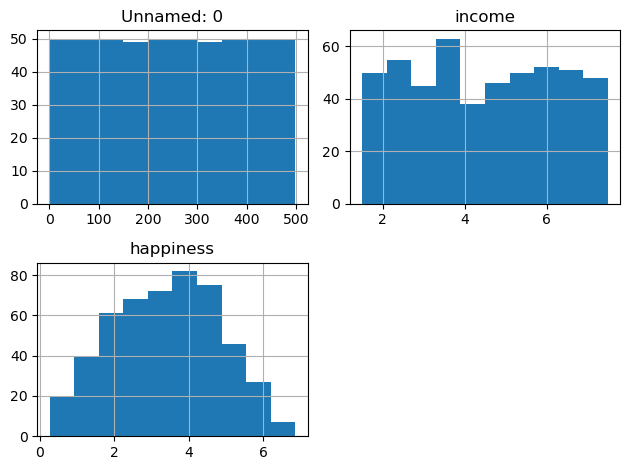

In [11]:
data.hist()
plt.tight_layout()
plt.show()

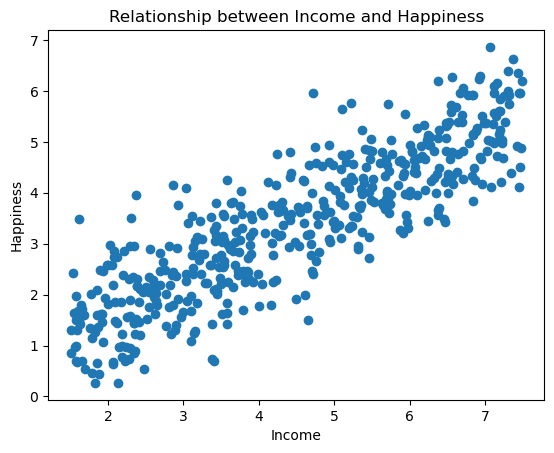

In [53]:
import matplotlib.pyplot as plt
plt.scatter(x=data["income"],y=data["happiness"])
plt.title("Relationship between Income and Happiness")
plt.xlabel("Income")
plt.ylabel("Happiness")
plt.show()

In [13]:
x=data[["income"]]    #independent variable
y=data[["happiness"]] #dependent variable

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [30]:
#splitting the data into tain and test
#train 80% and test 20%
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
print("The shape of X_train is:",x_train.shape)
print("The shape of X_test is:",x_test.shape)
print("The shape of y_train is:",y_train.shape)
print("The shape of X_test is:",y_test.shape)


The shape of X_train is: (398, 2)
The shape of X_test is: (100, 2)
The shape of y_train is: (398, 1)
The shape of X_test is: (100, 1)


In [26]:
#Building a model using sm.OLS
from sklearn.linear_model import LinearRegression
x=sm.add_constant(x)
model=sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     1483.
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          3.96e-151
Time:                        20:02:53   Log-Likelihood:                -540.72
No. Observations:                 498   AIC:                             1085.
Df Residuals:                     496   BIC:                             1094.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2043      0.089      2.299      0.0

In [32]:
y_pred=model.predict(x_test)

In [34]:
#mse
linreg_rmse=np.sqrt(mean_absolute_error(y_test, linreg_predictions))

In [35]:
#rmse
linreg_rmse=np.sqrt(mean_squared_error(y_test, linreg_predictions))
print("RMSE:", linreg_rmse)

RMSE: 0.7426234028055212


In [51]:
#R-squared (taken help of genAI and calculated by formula)
import warnings
warnings.filterwarnings("ignore")
sse=np.sum((y_test-linreg_predictions)**2)
sst=np.sum((y_test-np.mean(y_test))**2)
linreg_r2=1-(sse/sst)
#Adjusted R-squared (taken help of genAI and calculated by formula)
n=len(y_test)
p=x_test.shape[1]
linreg_adj_r2=1-((1-linreg_r2)*(n-1)/(n-p-1))
print("R²:",linreg_r2)
print("Adjusted R²:",linreg_adj_r2)

R²: happiness    0.740126
dtype: float64
Adjusted R²: happiness    0.734767
dtype: float64


In [48]:
#tabulation (taken little help from genAI)
final_result= pd.DataFrame({'Type': ['RMSE','R-Squared','Adjusted R-Squared'],'Value':[linreg_rmse, linreg_r2, linreg_adj_r2]})
print(final_result)

                 Type                                 Value
0                RMSE                              0.742623
1           R-Squared  happiness    0.740126
dtype: float64
2  Adjusted R-Squared  happiness    0.734767
dtype: float64
